In [5]:
#The code in this block comes directly from data_sort_and_split.ipynb
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

heart_data = pd.read_csv("heart.csv")

heart_data['Sex_F'] = heart_data['Sex'].map({'M': 0, 'F': 1})
heart_data['ExerciseAngina'] = heart_data['ExerciseAngina'].map({'N': 0, 'Y': 1})
heart_data = heart_data.drop(columns=['Sex'])

heart_data['ChestPainType'] = pd.Categorical(heart_data['ChestPainType'], categories=['ASY', 'ATA', 'NAP', 'TA'])
heart_data['RestingECG'] = pd.Categorical(heart_data['RestingECG'], categories=['Normal', 'LVH', 'ST'])
heart_data['ST_Slope'] = pd.Categorical(heart_data['ST_Slope'], categories=['Up', 'Flat', 'Down'])

categorical_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']
heart_data = pd.get_dummies(heart_data, columns=categorical_cols, drop_first=True, dtype=int)

feature_matrix = heart_data.drop("HeartDisease", axis=1)
target_labels = heart_data["HeartDisease"]

features_train, features_test, targets_train, targets_test = train_test_split(
    feature_matrix,
    target_labels,
    test_size=0.20,
    random_state=42,
    stratify= target_labels
)
#scaling performed because KNN is distance based so without scaling larger values can disturb the distance calculation
scaler = StandardScaler()
scaler.fit(features_train)
#transforming both sets using the training parameters
features_train_scaled = scaler.transform(features_train)
features_test_scaled = scaler.transform(features_test)


In [6]:
#K-Nearest Neighbors model creation
#using 1-20 values of k to know which performs the best
k_values = range(1,21)
accuracies = []
for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(features_train_scaled,targets_train)
    predictions = knn_model.predict(features_test_scaled)
    accuracy = accuracy_score(targets_test,predictions)
    accuracies.append(accuracy)
best_k = k_values[accuracies.index(max(accuracies))]
print("Best k:",best_k)
print("Best Validation accuracy :",max(accuracies))

Best k: 7
Best Validation accuracy : 0.9130434782608695


In [15]:
#Model Training for KNN
#Rebuild the model using the best k values which is found in the previous block of code
final_knn_model = KNeighborsClassifier(n_neighbors=best_k)
final_knn_model.fit(features_train_scaled,targets_train)
final_prediction = final_knn_model.predict(features_test_scaled)





final_proba = final_knn_model.predict_proba(features_test_scaled)[:, 1]

precision = precision_score(targets_test, final_prediction)
recall    = recall_score(targets_test, final_prediction)
f1        = f1_score(targets_test, final_prediction)
roc_auc   = roc_auc_score(targets_test, final_proba)

print("KNN Model Metrics")
print(f"Accuracy :", round(accuracy_score(targets_test,final_prediction),5))
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

KNN Model Metrics
Accuracy : 0.91304
Precision: 0.9135
Recall   : 0.9314
F1-Score : 0.9223
ROC-AUC  : 0.9290


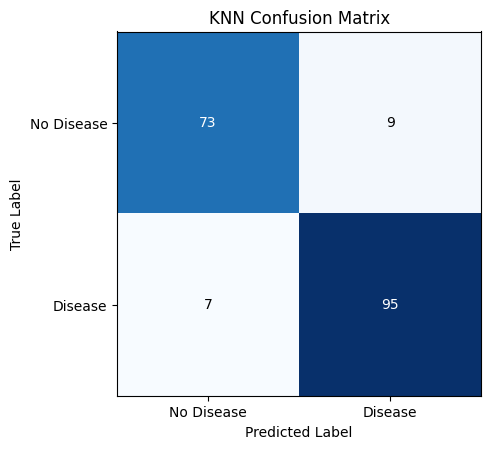

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Why: We generate a standard confusion matrix array to identify True/False Positives and Negatives.
cm = confusion_matrix(targets_test, final_prediction)

# Why: figsize=(5,5) and the 2x2 nature of the data naturally create a square appearance.
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Why: Adding labels to the axes makes the matrix readable for medical professionals.
classes = ['No Disease', 'Disease']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# Why: We loop through the matrix to place the actual counts in the center of each square.
# Why: The color 'white' or 'black' is chosen based on the background darkness for contrast.
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('KNN Confusion Matrix')
plt.tight_layout()
plt.show()